In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
# ============================================
# 1. Imports and Setup
# ============================================
import os
import random
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid
from tqdm import tqdm



# Use GPU if available (Kaggle GPU runtime)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Running on:", device)

Running on: cuda


In [3]:
# ============================================
# 2. Set up directories (Kaggle paths)
# ============================================
base_dir = "/kaggle/working"
data_dir = os.path.join(base_dir, "data")

# Folder structure
train_orig_dir = os.path.join(data_dir, "train", "original")
train_masked_dir = os.path.join(data_dir, "train", "masked")
train_mask_dir = os.path.join(data_dir, "train", "mask")

test_orig_dir = os.path.join(data_dir, "test", "original")
test_masked_dir = os.path.join(data_dir, "test", "masked")
test_mask_dir = os.path.join(data_dir, "test", "mask")

checkpoint_dir = os.path.join(data_dir, "vaeac_checkpoints")
results_dir = os.path.join(data_dir, "results")

# Create directories
for d in [
    train_orig_dir, train_masked_dir, train_mask_dir,
    test_orig_dir, test_masked_dir, test_mask_dir,
    checkpoint_dir, results_dir
]:
    os.makedirs(d, exist_ok=True)
print("Directories ready at:", data_dir)

Directories ready at: /kaggle/working/data


In [4]:

# ============================================
# 3. Load MNIST Dataset
# ============================================
transform_to_tensor = transforms.ToTensor()
train_dataset_raw = datasets.MNIST(root=data_dir, train=True, download=True, transform=transform_to_tensor)
test_dataset_raw = datasets.MNIST(root=data_dir, train=False, download=True, transform=transform_to_tensor)

100%|██████████| 9.91M/9.91M [00:00<00:00, 55.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.55MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 13.7MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.32MB/s]


In [5]:
# ============================================
# 4. Mask generation utilities
# ============================================
IMG_H, IMG_W = 28, 28

def generate_rect_mask(h, w, area_frac=0.3):
    total = h * w
    target_missing = max(1, int(total * area_frac))
    for _ in range(20):
        rect_h = random.randint(1, h)
        rect_w = max(1, target_missing // rect_h)
        if rect_w <= w:
            break
    rect_h, rect_w = min(rect_h, h), min(rect_w, w)
    top, left = random.randint(0, h - rect_h), random.randint(0, w - rect_w)
    mask = np.ones((h, w), dtype=np.uint8)
    mask[top:top+rect_h, left:left+rect_w] = 0
    return mask

def apply_mask_pil(pil_img, mask):
    arr = np.array(pil_img).astype(np.uint8)
    masked = arr * mask
    return Image.fromarray(masked.astype(np.uint8))


In [6]:

# ============================================
# 5. Save images into clean folder structure
# ============================================
def save_masked_images(dataset, orig_dir, masked_dir, mask_dir, split="train"):
    if len(os.listdir(orig_dir)) == 0:
        print(f"Generating {split} images...")
        for i, (img_tensor, label) in enumerate(tqdm(dataset, desc=f"{split.capitalize()} Set")):
            img_np = (img_tensor.squeeze(0).numpy() * 255).astype(np.uint8)
            pil_img = Image.fromarray(img_np, mode="L")

            mask = generate_rect_mask(IMG_H, IMG_W, area_frac=0.3)
            masked_img = apply_mask_pil(pil_img, mask)

            fname = f"{i:05d}.png"
            pil_img.save(os.path.join(orig_dir, fname))
            masked_img.save(os.path.join(masked_dir, fname))
            Image.fromarray((mask * 255).astype(np.uint8)).save(os.path.join(mask_dir, fname))
        print(f"{split.capitalize()} images saved successfully.")
    else:
        print(f"{split.capitalize()} data already exists — skipping generation.")

# Generate both splits
save_masked_images(train_dataset_raw, train_orig_dir, train_masked_dir, train_mask_dir, "train")
save_masked_images(test_dataset_raw, test_orig_dir, test_masked_dir, test_mask_dir, "test")


Generating train images...


Train Set:   0%|          | 0/60000 [00:00<?, ?it/s]/tmp/ipykernel_37/6677344.py:9: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  pil_img = Image.fromarray(img_np, mode="L")
Train Set: 100%|██████████| 60000/60000 [00:48<00:00, 1233.14it/s]


Train images saved successfully.
Generating test images...


Test Set: 100%|██████████| 10000/10000 [00:08<00:00, 1215.65it/s]

Test images saved successfully.


In [7]:

# ============================================
# 6. Dataset Class (optimized)
# ============================================
class MaskedMNISTDataset(Dataset):
    def __init__(self, orig_dir, masked_dir, mask_dir, transform=None):
        self.orig_dir = orig_dir
        self.masked_dir = masked_dir
        self.mask_dir = mask_dir
        self.transform = transform
        self.filenames = sorted(os.listdir(orig_dir))

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        fname = self.filenames[idx]
        orig = Image.open(os.path.join(self.orig_dir, fname)).convert("L")
        masked = Image.open(os.path.join(self.masked_dir, fname)).convert("L")
        mask = Image.open(os.path.join(self.mask_dir, fname)).convert("L")

        if self.transform:
            orig = self.transform(orig)
            masked = self.transform(masked)
            mask = self.transform(mask)

        mask = (mask > 0.5).float()
        return orig, masked, mask


In [8]:
# ============================================
# 7. Model Definition (VAEAC)
# ============================================
latent_dim = 16

class Encoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 4, 2, 1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1),
            nn.ReLU()
        )
        self.fc_mu = nn.Linear(64*7*7, latent_dim)
        self.fc_logvar = nn.Linear(64*7*7, latent_dim)
    def forward(self, x):
        h = self.conv(x).view(x.size(0), -1)
        return self.fc_mu(h), self.fc_logvar(h)

class Prior(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(2, 32, 4, 2, 1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1),
            nn.ReLU()
        )
        self.fc_mu = nn.Linear(64*7*7, latent_dim)
        self.fc_logvar = nn.Linear(64*7*7, latent_dim)
    def forward(self, x_b, b):
        xb = torch.cat([x_b, b], dim=1)
        h = self.conv(xb).view(xb.size(0), -1)
        return self.fc_mu(h), self.fc_logvar(h)

class Decoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.fc = nn.Linear(latent_dim + 2*IMG_H*IMG_W, 64*7*7)
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 4, 2, 1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, 4, 2, 1),
            nn.Sigmoid()
        )
    def forward(self, z, x_b, b):
        xb_flat = torch.cat([x_b.view(x_b.size(0), -1), b.view(b.size(0), -1)], dim=1)
        h = torch.cat([z, xb_flat], dim=1)
        h = self.fc(h).view(h.size(0), 64, 7, 7)
        return self.deconv(h)

class VAEAC(nn.Module):
    def __init__(self, latent_dim=16):
        super().__init__()
        self.encoder = Encoder(latent_dim)
        self.prior = Prior(latent_dim)
        self.decoder = Decoder(latent_dim)
    def forward(self, x, x_b, b):
        mu_q, logvar_q = self.encoder(x)
        std = torch.exp(0.5 * logvar_q)
        z = mu_q + torch.randn_like(std) * std
        mu_p, logvar_p = self.prior(x_b, b)
        x_recon = self.decoder(z, x_b, b)
        return x_recon, mu_p, logvar_p, mu_q, logvar_q


In [9]:
# ============================================
# 8. Loss Function
# ============================================
def vaeac_loss(recon_x, x, mu, logvar, mask):
    missing = 1.0 - mask
    bce = F.binary_cross_entropy(recon_x * missing, x * missing, reduction="sum")
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return bce + kl


In [10]:
# ============================================
# 9. Training Setup
# ============================================
batch_size = 128
epochs = 20
learning_rate = 1e-3

train_dataset = MaskedMNISTDataset(train_orig_dir, train_masked_dir, train_mask_dir, transform=transforms.ToTensor())
test_dataset  = MaskedMNISTDataset(test_orig_dir, test_masked_dir, test_mask_dir, transform=transforms.ToTensor())

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

vaeac = VAEAC(latent_dim).to(device)
optimizer = torch.optim.Adam(vaeac.parameters(), lr=learning_rate)


In [11]:

# ============================================
# 10. Training Loop
# ============================================
for epoch in range(epochs):
    vaeac.train()
    total_loss = 0
    print(f"\nEpoch {epoch+1}/{epochs}")
    for data, masked, mask in tqdm(train_loader, desc=f"Training Epoch {epoch+1}", leave=False):
        data, masked, mask = data.to(device), masked.to(device), mask.to(device)
        optimizer.zero_grad()
        recon, mu_p, logvar_p, mu_q, logvar_q = vaeac(data, masked, mask)
        loss = vaeac_loss(recon, data, mu_q, logvar_q, mask)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(train_loader.dataset)
    print(f"Epoch {epoch+1} completed. Avg Loss: {avg_loss:.4f}")
    torch.save(vaeac.state_dict(), os.path.join(checkpoint_dir, f"vaeac_epoch_{epoch+1}.pth"))




Epoch 1/5


Epoch 1 completed. Avg Loss: 76.0907

Epoch 2/5


Epoch 2 completed. Avg Loss: 64.2547

Epoch 3/5


Epoch 3 completed. Avg Loss: 60.9927

Epoch 4/5


Epoch 4 completed. Avg Loss: 59.0908

Epoch 5/5


Epoch 5 completed. Avg Loss: 57.9455


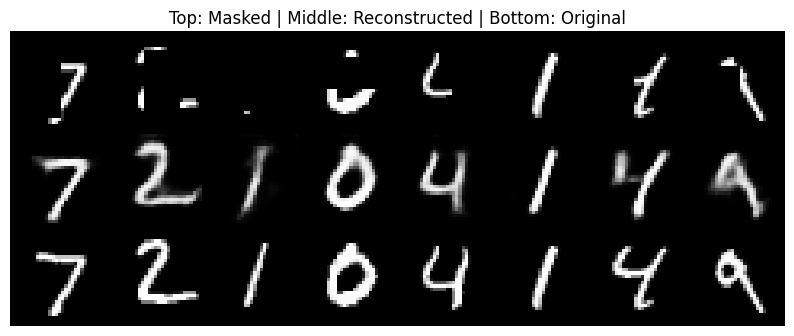

In [12]:

# ============================================
# 11. Visualization
# ============================================
vaeac.eval()
with torch.no_grad():
    for data, masked, mask in test_loader:
        data, masked, mask = data.to(device), masked.to(device), mask.to(device)
        recon, *_ = vaeac(data, masked, mask)
        n = 8
        imgs = torch.cat([masked[:n], recon[:n], data[:n]])
        grid = make_grid(imgs, nrow=n)
        plt.figure(figsize=(10, 4))
        plt.imshow(grid[0].cpu(), cmap="gray")
        plt.axis("off")
        plt.title("Top: Masked | Middle: Reconstructed | Bottom: Original")
        plt.show()
        break
